# Collision Avoidance (Sec 5.4)

Optimize per-face reflectance of a cube satellite over time to deviate from
the nominal orbit at collision time, then return to baseline.

In [1]:
import numpy as np
from pathlib import Path
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax

import base, designer, estimation, nn, raytracing, srp_simulation, integrator, physics
from utils import load_trajectory, sample_moonsun_cubic

jax.config.update('jax_enable_x64', True)

OBJECT_NAME = 'cuboid_6faces/cuboid_6faces'
DESIGN_NAME = 'face_albedo_sweep'
PLOT_DIR = base.PROJECT_ROOT / 'plots' / 'discobox_experiments'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

/Users/charlesc/anaconda3/envs/photonsxforce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
face_specs = [designer.make_face_albedo_spec(f'Face_{i+1}') for i in range(6)]
cuboid_albedo_design = designer.build_face_albedo_design(OBJECT_NAME, face_specs)
designer.my_design = cuboid_albedo_design

SUN_GRID = (90, 180)
LOAD_PRECOMPUTED = True
force_prefix = str(Path(base.get_force_path(OBJECT_NAME, DESIGN_NAME)))

if LOAD_PRECOMPUTED:
    for s in ['_force', '_torque', '_directions', '_parameters']:
        np.load(force_prefix + s + '.npy')
    print('Loaded precomputed force/torque maps')
else:
    mesh = raytracing.load_mesh(base.get_mesh_name(OBJECT_NAME))
    force, torque, dirs, params = srp_simulation.build_force_map(
        SUN_GRID, 10_000, estimation.estimate_backward, mesh, cuboid_albedo_design, profile_interval=1000)
    for s, a in [('_force', force), ('_torque', torque), ('_directions', dirs), ('_parameters', params)]:
        np.save(force_prefix + s + '.npy', np.array(a).reshape(-1, 3 if 'param' not in s else cuboid_albedo_design.shape))

nn.train_combined_proxy(
    OBJECT_NAME, DESIGN_NAME, SUN_GRID,
    feature_suffix='_parameters.npy', direction_suffix='_directions.npy',
    force_suffix='_force.npy', torque_suffix='_torque.npy',
    weight_prefix='combined', checkpoint_name='combined_training_checkpoint.pkl',
    load_pretrained=True, num_hidden_layers=5, hidden_width=192, max_steps=6_000,
    log_every=1000, diag_every=999)

Loaded precomputed force/torque maps


{'parameters': (Array([[ 0.41648949, -0.88365777, -0.23045944, ...,  0.15189775,
          -0.41360474,  1.01953563],
         [-0.16557002, -0.21538515, -0.75457595, ..., -0.59512795,
          -0.659611  , -0.27718003],
         [ 0.41386646,  0.15921263, -0.24689061, ...,  1.22426471,
           0.14088092, -0.03809257],
         ...,
         [ 0.03346501,  0.09146622, -0.14760209, ...,  0.61851763,
          -0.35203832, -0.14162886],
         [-0.39798302, -0.31711514, -0.17593453, ...,  0.3861237 ,
           0.09393042, -0.10447508],
         [ 1.14468011, -0.89639721,  0.29456177, ...,  1.12444074,
           0.56197312, -0.70473481]], dtype=float64),
  Array([[ 0.16702859, -0.13287784,  0.13379934, ..., -0.07241153,
          -0.13402167, -0.00567101],
         [-0.00599582,  0.13142907,  0.15486253, ..., -0.15896069,
          -0.09068662, -0.07385809],
         [ 0.13748503,  0.13590196,  0.0463221 , ..., -0.05876921,
           0.12044701,  0.14291058],
         ...,
     

In [3]:
# Scenario
SIM_HOURS = 144
STEP_SIZE = 120.0
STEP_COUNT = int(SIM_HOURS * 3600 / STEP_SIZE)
DOWNSAMPLE = 10
N_CTRL = (STEP_COUNT) // DOWNSAMPLE + 1

SC_MASS = 100.0
MOI = jnp.array([1.0, 1.0, 1.0], dtype=jnp.float64)
BOX_AREA = 50.0
N_FACES = 6

trajectory = load_trajectory(base.drive_path + 'trajectories/gps08.csv', limit=None)
pos0 = jnp.asarray(trajectory.position[0], dtype=jnp.float64)
vel0 = jnp.asarray(trajectory.velocity[0], dtype=jnp.float64)
sun0 = jnp.asarray(trajectory.sun[0], dtype=jnp.float64)
t0 = float(trajectory.time[0])
t1 = t0 + SIM_HOURS * 3600
sun_positions = jnp.asarray(trajectory.sun, dtype=jnp.float64)
sun_times = jnp.asarray(trajectory.time, dtype=jnp.float64)
ctrl_times = jnp.asarray(t0 + STEP_SIZE * DOWNSAMPLE * jnp.arange(N_CTRL), dtype=jnp.float64)

# Quaternion helpers
def qmul(q1, q2):
    w1,x1,y1,z1 = q1; w2,x2,y2,z2 = q2
    return jnp.array([w1*w2-x1*x2-y1*y2-z1*z2, w1*x2+x1*w2+y1*z2-z1*y2,
                       w1*y2-x1*z2+y1*w2+z1*x2, w1*z2+x1*y2-y1*x2+z1*w2])
def qnorm(q): return q / jnp.linalg.norm(q)
def q2r(q):
    w,x,y,z = qnorm(q)
    return jnp.array([[1-2*(y*y+z*z),2*(x*y-w*z),2*(x*z+w*y)],
                       [2*(x*y+w*z),1-2*(x*x+z*z),2*(y*z-w*x)],
                       [2*(x*z-w*y),2*(y*z+w*x),1-2*(x*x+y*y)]])
def qdot(q, w): return 0.5 * qmul(q, jnp.array([0., w[0], w[1], w[2]]))
def r2q(R):
    w = jnp.sqrt(jnp.maximum(0, 1+jnp.trace(R)))/2
    x = jnp.copysign(jnp.sqrt(jnp.maximum(0, 1+R[0,0]-R[1,1]-R[2,2]))/2, R[2,1]-R[1,2])
    y = jnp.copysign(jnp.sqrt(jnp.maximum(0, 1-R[0,0]+R[1,1]-R[2,2]))/2, R[0,2]-R[2,0])
    z = jnp.copysign(jnp.sqrt(jnp.maximum(0, 1-R[0,0]-R[1,1]+R[2,2]))/2, R[1,0]-R[0,1])
    return jnp.array([w,x,y,z])

# Initial attitude (yaw-steering)
zs = -pos0 / jnp.linalg.norm(pos0)
ys = jnp.cross(sun0 / jnp.linalg.norm(sun0), -zs); ys = ys / jnp.linalg.norm(ys)
xs = jnp.cross(ys, zs); xs = xs / jnp.linalg.norm(xs)
q0 = qnorm(r2q(jnp.column_stack([xs, ys, zs])))
omega0 = jnp.deg2rad(jnp.array([0.05, 0.05, 0.05]))
state0 = (pos0, vel0, q0, omega0)

print(f'{SIM_HOURS}h ({SIM_HOURS//24}d), {STEP_COUNT} steps, {N_CTRL} control points')

144h (6d), 4320 steps, 433 control points


In [4]:
# NN proxy
nn_dir = Path(base.get_nn_weight_path(OBJECT_NAME, DESIGN_NAME))
bundle = {
    'params': tuple(jnp.asarray(p, dtype=jnp.float64) for p in nn.load_nn_parameters(nn_dir / 'combined_parameters.bin')),
    'feat': tuple(jnp.asarray(s, dtype=jnp.float64) for s in nn.load_nn_parameters(nn_dir / 'combined_ray_stats.bin')),
    'tgt': tuple(jnp.asarray(s, dtype=jnp.float64) for s in nn.load_nn_parameters(nn_dir / 'combined_target_stats.bin')),
}

def eval_proxy(sun_body, albedo):
    feat = jnp.concatenate([sun_body, 0.5 * (albedo + 1.0)])
    w = nn.whiten_with_stats(feat, bundle['feat'])
    pred = nn.unwhiten(0.5 * (nn.mlp(w, bundle['params']) + 1.0), bundle['tgt'])
    return BOX_AREA * pred[:3], pred[3:]

def softsign(x): return x / (1.0 + jnp.abs(x))
def params_to_albedo(raw): return jnp.clip(softsign(raw), 0.0, 1.0)

def build_provider(albedo_table):
    def provider(position, time, quat):
        ir = jnp.clip(jnp.searchsorted(ctrl_times, time, side='right'), 1, albedo_table.shape[0]-1)
        il = ir - 1
        a = jnp.clip((time - ctrl_times[il]) / jnp.maximum(ctrl_times[ir] - ctrl_times[il], 1e-9), 0., 1.)
        albedo = (1-a) * albedo_table[il] + a * albedo_table[ir]
        sun_pos = sample_moonsun_cubic(time, sun_positions, sun_times)
        R = q2r(quat)
        sun_body = R.T @ ((sun_pos - position) / jnp.maximum(jnp.linalg.norm(sun_pos - position), 1e-12))
        f, t = eval_proxy(sun_body, albedo)
        return R @ f / SC_MASS, t
    return provider

def dynamics(state, time, provider, moi):
    pos, vel, quat, omega = state
    g = -3.986004418e14 * pos / jnp.linalg.norm(pos)**3
    srp_acc, torque = provider(pos, time, quat)
    return (vel, g + srp_acc, qdot(quat, omega),
            (torque - jnp.cross(omega, moi * omega)) / moi)

def rk4q(state, time, f, param, dt, moi):
    def sub(a, b, k):
        s = tuple(si + a*dt*ki for si, ki in zip(state, k))
        return f(s, time + b*dt, param, moi)
    k1 = sub(0,0, tuple(jnp.zeros_like(s) for s in state))
    k2 = sub(.5,.5,k1); k3 = sub(.5,.5,k2); k4 = sub(1,1,k3)
    new = tuple(s+(dt/6)*(a+2*b+2*c+d) for s,a,b,c,d in zip(state,k1,k2,k3,k4))
    return (new[0], new[1], qnorm(new[2]), new[3])

def simulate(raw):
    prov = build_provider(params_to_albedo(raw))
    dt = (t1 - t0) / STEP_COUNT
    def step(c, t): return rk4q(c, t, dynamics, prov, dt, MOI), c
    final, hist = jax.lax.scan(step, state0, t0 + dt * jnp.arange(STEP_COUNT))
    hist = jax.tree.map(lambda h, f: jnp.concatenate([h, f[None]], axis=0), hist, final)
    return hist

In [5]:
# Baseline + loss
COLLIDE_TIME = 72 * 3600.0
COLLIDE_SIGMA = 3 * 3600.0
RECOVER_START = COLLIDE_TIME + 3 * 3600.0
W_REC, W_TERM, W_COL = 2.0, 5.0, 17.0

sim_times = t0 + jnp.arange(STEP_COUNT + 1) * STEP_SIZE
baseline_pos = jax.jit(lambda: simulate(jnp.zeros((N_CTRL, N_FACES)))[0])()

def safe_norm(x, axis=None):
    return jnp.sqrt(jnp.sum(x**2, axis=axis) + 1e-6**2)

def loss_fn(raw):
    hist = simulate(raw)
    dist_km = safe_norm(hist[0] - baseline_pos, axis=1) * 1e-3
    cw = jnp.exp(-0.5 * ((sim_times - (t0 + COLLIDE_TIME)) / COLLIDE_SIGMA)**2)
    rm = (sim_times >= (t0 + RECOVER_START)).astype(jnp.float64)
    rec = jnp.sum(dist_km * rm) / jnp.maximum(jnp.sum(rm), 1.)
    term = safe_norm(hist[0][-1] - baseline_pos[-1]) * 1e-3
    col = jnp.sum(dist_km * cw) / jnp.sum(cw)
    return W_REC * rec + W_TERM * term - W_COL * col

print(f'Collision at {COLLIDE_TIME/3600:.0f}h, recovery from {RECOVER_START/3600:.0f}h')

Collision at 72h, recovery from 75h


In [6]:
# Optimization
N_ITERS = 200

_, noise_key = jax.random.split(jax.random.PRNGKey(0))
init_params = jax.random.uniform(noise_key, (N_CTRL, N_FACES), minval=0.5, maxval=2.0)

loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))
params = init_params
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)
losses, best_params, best_loss = [], init_params, float('inf')

for i in range(N_ITERS):
    l, g = loss_and_grad(params)
    if jnp.isnan(l) or jnp.any(jnp.isnan(g)):
        continue
    losses.append(float(l))
    if float(l) < best_loss:
        best_loss, best_params = float(l), params
    updates, opt_state = optimizer.update(g, opt_state, params)
    params = optax.apply_updates(params, updates)
    if i % 50 == 0 or i == N_ITERS - 1:
        print(f'iter {i:4d}  loss={l:.4f}')

print(f'Best loss: {best_loss:.4f}')

iter    0  loss=-0.0149


iter   50  loss=-0.4532


iter  100  loss=-1.6437


iter  150  loss=-4.0820


iter  199  loss=-5.4845
Best loss: -5.4845


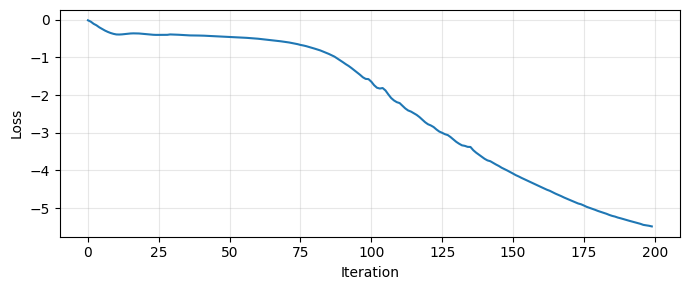

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'loss_trace.svg'))
plt.show()

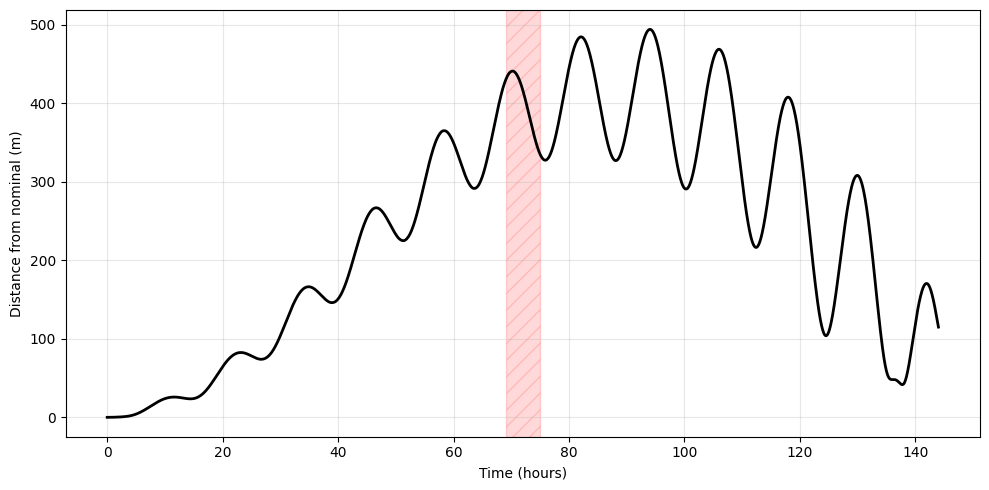

In [8]:
hist_opt = jax.jit(simulate)(best_params)
hours = np.arange(STEP_COUNT + 1) * STEP_SIZE / 3600
dist_opt = np.asarray(safe_norm(hist_opt[0] - baseline_pos, axis=1))

fig, ax = plt.subplots(figsize=(10, 5))
ch = COLLIDE_TIME / 3600
ax.axvspan(ch - COLLIDE_SIGMA/3600, ch + COLLIDE_SIGMA/3600, alpha=0.15, color='red', hatch='//')
ax.plot(hours, dist_opt, 'k-', lw=2)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Distance from nominal (m)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'inverse_discobox_collision_avoidance.svg'))
plt.show()

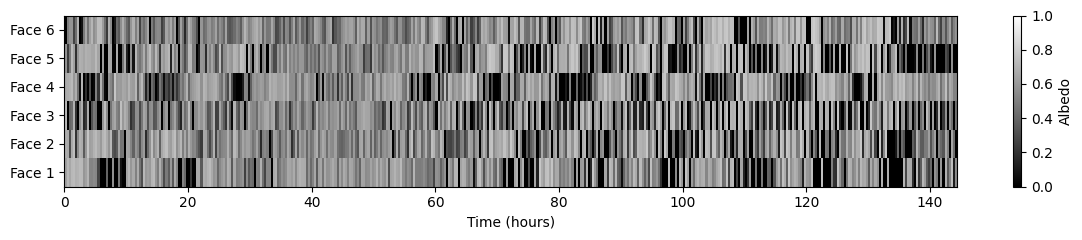

In [9]:
opt_albedo = np.asarray(params_to_albedo(best_params))
ch = np.asarray(ctrl_times - ctrl_times[0]) / 3600

fig, ax = plt.subplots(figsize=(12, 2.5))
dh = float(ch[1] - ch[0]) if len(ch) > 1 else 1.0
te = np.concatenate([ch, [ch[-1] + dh]])
im = ax.pcolormesh(te, np.arange(N_FACES + 1), opt_albedo.T, cmap='gray', vmin=0, vmax=1, shading='flat')
ax.set_xlabel('Time (hours)')
ax.set_yticks(np.arange(N_FACES) + 0.5)
ax.set_yticklabels([f'Face {i+1}' for i in range(N_FACES)])
plt.colorbar(im, ax=ax, label='Albedo')
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'inverse_discobox_albedo_schedule.png'), dpi=150)
plt.show()